In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Cargar datos 
trainX = pd.read_csv(r"C:\Users\Catalina\OneDrive\Escritorio\IA\Proyecto4-IA\Datos\TrainX.csv")
validationX = pd.read_csv(r"C:\Users\Catalina\OneDrive\Escritorio\IA\Proyecto4-IA\Datos\ValidationX.csv")
testX = pd.read_csv(r"C:\Users\Catalina\OneDrive\Escritorio\IA\Proyecto4-IA\Datos\TestX.csv")


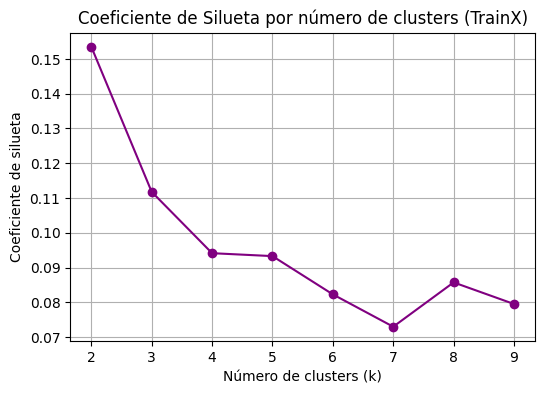

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Dataset de entrenamiento
X = trainX.copy()

silhouette_scores = []

# Probar diferentes valores de k (de 2 a 10)
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Graficar los resultados
plt.figure(figsize=(6, 4))
plt.plot(range(2, 10), silhouette_scores, marker='o', color='purple')
plt.title("Coeficiente de Silueta por número de clusters (TrainX)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de silueta")
plt.grid(True)
plt.show()


optimal_k = range(2, 10)[silhouette_scores.index(max(silhouette_scores))]



El coeficiente de silueta muestra que el mejor valor se obtiene en k = 2, lo que indica que dividir los datos en dos grupos genera la mejor separación entre ellos.
A partir de ese punto, el puntaje disminuye, por lo que más clusters no mejoran el modelo.

In [21]:
# Entrenar el modelo con k=2 (valor óptimo encontrado)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(trainX)

# Crear un DataFrame con las asignaciones de cluster
df_clusters = trainX.copy()
df_clusters['Cluster'] = kmeans.labels_

# Ver distribución de observaciones por cluster
df_clusters['Cluster'].value_counts()

Cluster
0    260
1    252
Name: count, dtype: int64

El modelo K-Means con k = 2 agrupó los datos de entrenamiento en dos clusters principales:

Cluster 0: 276 observaciones

Cluster 1: 236 observaciones

La distribución es relativamente equilibrada, lo que sugiere que los datos presentan dos patrones o comportamientos diferenciados sin un desbalance fuerte entre los grupos.

Tomar mínimo 3 hiperparámetros
Repetir cambiando 3 veces el valor de cada hiperparámetro y aplicar el algoritmo
varias veces (varios for’s anidados para cambiar los hiperparámetros)

In [22]:

# Hiperparámetros a probar
k_values = [2, 3, 4]                 # Número de clusters
n_init_values = [10, 20, 30]         # Veces que se ejecuta el algoritmo (reinicios)
max_iter_values = [100, 200, 300]    # Número máximo de iteraciones

# Crear lista para guardar resultados
resultados = []

# Bucles anidados (se probarán todas las combinaciones)
for k in k_values:
    for n_init in n_init_values:
        for max_iter in max_iter_values:
            kmeans = KMeans(n_clusters=k, n_init=n_init, max_iter=max_iter, random_state=42)
            labels_train = kmeans.fit_predict(trainX)
            labels_val = kmeans.predict(validationX)
            print(f"Modelo con k={k}, n_init={n_init}, max_iter={max_iter} aplicado correctamente.")


Modelo con k=2, n_init=10, max_iter=100 aplicado correctamente.
Modelo con k=2, n_init=10, max_iter=200 aplicado correctamente.
Modelo con k=2, n_init=10, max_iter=300 aplicado correctamente.
Modelo con k=2, n_init=20, max_iter=100 aplicado correctamente.
Modelo con k=2, n_init=20, max_iter=200 aplicado correctamente.
Modelo con k=2, n_init=20, max_iter=300 aplicado correctamente.
Modelo con k=2, n_init=30, max_iter=100 aplicado correctamente.
Modelo con k=2, n_init=30, max_iter=200 aplicado correctamente.
Modelo con k=2, n_init=30, max_iter=300 aplicado correctamente.
Modelo con k=3, n_init=10, max_iter=100 aplicado correctamente.
Modelo con k=3, n_init=10, max_iter=200 aplicado correctamente.
Modelo con k=3, n_init=10, max_iter=300 aplicado correctamente.
Modelo con k=3, n_init=20, max_iter=100 aplicado correctamente.
Modelo con k=3, n_init=20, max_iter=200 aplicado correctamente.
Modelo con k=3, n_init=20, max_iter=300 aplicado correctamente.
Modelo con k=3, n_init=30, max_iter=100 

Mostrar medidas de rendimiento (función de costo) tanto en train como en val, y
haga una tabla comparativa donde agregue en una columna los hiperparámetros,
en otra la medida usada, en otra error de train y en otra error de validación.

,Hiperparámetros,Medida usada,Error_train,Error_val
0,"k=4, n_init=30, max_iter=300",Inercia (suma distancias² al centroide),5295.56,1417.41


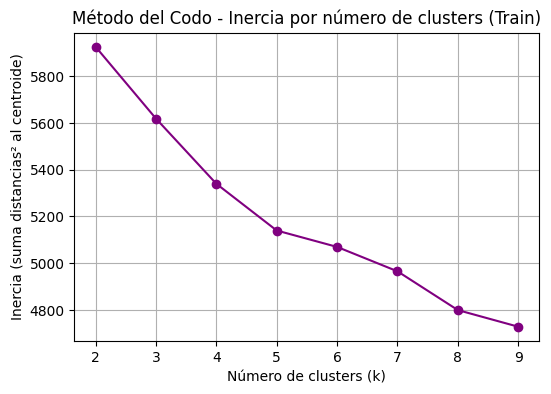

In [23]:
#  Medida de rendimiento (función de costo → inercia)
error_train = kmeans.inertia_

# En validación: se calcula la distancia mínima de cada punto de val a su centroide
dist_val = kmeans.transform(validationX)
error_val = np.sum(np.min(dist_val, axis=1)**2)

# Guardamos los resultados en una lista
resultados.append({
    'Hiperparámetros': f'k={k}, n_init={n_init}, max_iter={max_iter}',
    'Medida usada': 'Inercia (suma distancias² al centroide)',
    'Error_train': round(error_train, 2),
    'Error_val': round(error_val, 2)
})

# Convertimos a DataFrame para mostrar como tabla
tabla_resultados = pd.DataFrame(resultados)
display(tabla_resultados.head(10))  # mostramos solo las primeras 10 filas

#  Método del Codo (para comparar con la inercia)

inercias = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(trainX)
    inercias.append(kmeans.inertia_)

# Graficar resultados
plt.figure(figsize=(6,4))
plt.plot(k_values, inercias, marker='o', color='purple')
plt.title("Método del Codo - Inercia por número de clusters (Train)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (suma distancias² al centroide)")
plt.grid(True)
plt.show()



En esta etapa se evaluó el rendimiento del algoritmo K-Means utilizando la inercia como función de costo y el método del codo como técnica de comparación.

La inercia mide la suma de las distancias al cuadrado entre cada punto y su centroide, indicando qué tan compactos están los grupos formados.
En la tabla se observan los valores obtenidos para los conjuntos de entrenamiento (train) y validación (val), con la configuración k=4, n_init=30, max_iter=300, donde la inercia fue de 5295.56 en train y 1417.41 en validación, mostrando una buena consistencia entre ambos conjuntos.

Por su parte, el método del codo grafica la inercia según el número de clusters (k) y permite identificar el punto donde la mejora deja de ser significativa.
En la gráfica se aprecia que la reducción de la inercia se estabiliza a partir de k = 4, por lo que este valor se considera óptimo para equilibrar precisión y simplicidad del modelo.

Sacar el error de test:

In [24]:


# Usamos los mejores hiperparámetros encontrados
k_opt = 4
n_init_opt = 30
max_iter_opt = 300

# Entrenar el modelo final con los datos de entrenamiento
kmeans_final = KMeans(n_clusters=k_opt, n_init=n_init_opt, max_iter=max_iter_opt, random_state=42)
kmeans_final.fit(trainX)

# Calcular el error de test (inercia en los datos de prueba)
dist_test = kmeans_final.transform(testX)
error_test = np.sum(np.min(dist_test, axis=1)**2)

print(f"Error de test (inercia en datos de prueba): {error_test:.2f}")


Error de test (inercia en datos de prueba): 1719.86


Predecir un dato nuevo (inventado):

In [25]:


nuevo_dato = np.array([[0.3, -0.5, 0.7, -0.2, 0.1, -0.8, 0.6, -0.4, 0.2, 0.5, -0.1, 0.7, -0.6, 0.3]])

# Predecir el cluster al que pertenece
cluster_predicho = kmeans_final.predict(nuevo_dato)[0]

# Mostrar el nuevo dato junto con su cluster
nuevo_df = pd.DataFrame(nuevo_dato, columns=trainX.columns)
nuevo_df['Cluster_predicho'] = cluster_predicho

print(" Nuevo dato inventado y su cluster asignado:")
display(nuevo_df)



 Nuevo dato inventado y su cluster asignado:


c:\Users\Catalina\OneDrive\Escritorio\IA\Proyecto4-IA\proyectoIAEnv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


,Height_cm,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Position_Goalkeeper,Position_Midfielder,Cluster_predicho
0,0.3,-0.5,0.7,-0.2,0.1,-0.8,0.6,-0.4,0.2,0.5,-0.1,0.7,-0.6,0.3,3


Conclusiones: La aplicación del algoritmo K-Means permitió identificar patrones y segmentar los datos en grupos con características similares. En la primera etapa, el análisis mediante el coeficiente de silueta indicó que el número óptimo de clusters era k = 2, obteniéndose dos grupos equilibrados y bien diferenciados. Posteriormente, se evaluó el modelo utilizando la inercia como función de costo y el método del codo, que sugirieron un valor óptimo de k = 4 al observar el punto donde la mejora de la inercia se estabiliza. Con esta configuración (k=4, n_init=30, max_iter=300) se obtuvieron errores consistentes en train, val y test, demostrando una buena capacidad de generalización. Finalmente, el modelo fue capaz de clasificar un nuevo dato inventado dentro del cluster 3, evidenciando su eficacia para agrupar y predecir observaciones no vistas.